# Notebook 15 — Structured pruning baseline scores and removable groups

**Purpose.** Enumerate physically removable CNN1D channels, verify their direct
parameter/FLOP effects, and compute the baseline saliency scores needed for the
G1 causal comparison.

This notebook deliberately implements the **screening** suite first:

- deterministic random rank;
- L1 channel magnitude;
- first-order Taylor saliency;
- Fisher-style squared first-order saliency;
- BatchNorm scale where available.

Exact reproductions/adaptations of Undecayed, FairGRAPE, CATRO, and
latency-aware solvers should be added only after G1 confirms that the proposed
semantic object is worth pursuing.

**Outputs**

- `results/saber/15_baselines/prunable_groups.csv`
- `results/saber/15_baselines/group_baseline_scores.csv`
- layer-cost and score-diagnostic figures

In [1]:
# Colab/repository bootstrap
from pathlib import Path
import os, sys, json, subprocess, platform

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

# Override with %env SABER_REPO=/your/path if your repository is elsewhere.
candidates = [
    os.environ.get("SABER_REPO"),
    "/content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression",
    str(Path.cwd()),
]
REPO = None
for candidate in candidates:
    if not candidate:
        continue
    p = Path(candidate).expanduser()
    if (p / "src").is_dir() and (p / "config").is_dir():
        REPO = p.resolve()
        break
if REPO is None:
    raise FileNotFoundError(
        "Repository not found. Set SABER_REPO or edit the candidate path."
    )
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

print("Repository:", REPO)
print("Python:", sys.version.split()[0], "| Platform:", platform.platform())

Mounted at /content/drive
Repository: /content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression
Python: 3.13.15 | Platform: Linux-6.6.122+-x86_64-with-glibc2.35


In [2]:
# Install only the small SABER extension requirements.
# The original repository requirements must already be installed.
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-saber.txt"],
        check=True,
    )

In [3]:
import yaml
from src.saber.adapters import SaberRepo

repo = SaberRepo.discover(REPO)
with open(REPO / "config" / "saber.yaml", "r", encoding="utf-8") as handle:
    SABER_CFG = yaml.safe_load(handle)

OUTPUT_ROOT = repo.output_root
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("SABER output root:", OUTPUT_ROOT)
print("Config branch:", SABER_CFG["project"]["branch"])

SABER output root: /content/drive/MyDrive/IoT_Trust_Research/iot-trust-compression/results/saber
Config branch: saber-ids-method


In [4]:
from src.saber.bridge_ciciot import load_bridge
TRAIN_LOADER, VAL_LOADER, TEST_LOADER, MODEL, CLASS_NAMES = load_bridge()
print('bridge OK:', len(CLASS_NAMES), 'classes')

bridge OK: 34 classes


In [5]:
# Repository bridge: auto-discovery first, explicit override second.
#
# If auto-discovery fails, set these objects using the same loader/model
# construction cells from the completed Computer Networks notebooks:
#   TRAIN_LOADER = ...
#   VAL_LOADER = ...
#   TEST_LOADER = ...
#   MODEL = ...
#   CLASS_NAMES = [...]
#
# MODEL must be the uncompressed CNN1D anchor and loaders must use the frozen
# train/validation/test split.

import torch
from src.saber.adapters import (
    auto_discover_loaders,
    auto_build_cnn,
    discover_anchor_checkpoint,
    infer_class_names_from_results,
    unpack_batch,
)

TRAIN_LOADER = globals().get("TRAIN_LOADER")
VAL_LOADER = globals().get("VAL_LOADER")
TEST_LOADER = globals().get("TEST_LOADER")
MODEL = globals().get("MODEL")
CLASS_NAMES = globals().get("CLASS_NAMES")

if any(obj is None for obj in (TRAIN_LOADER, VAL_LOADER, TEST_LOADER)):
    TRAIN_LOADER, VAL_LOADER, TEST_LOADER, _DATA_BUNDLE = auto_discover_loaders(repo)

first_batch = next(iter(VAL_LOADER))
x0, y0, env0 = unpack_batch(first_batch)
raw_example = x0[: min(8, len(x0))].float()

if CLASS_NAMES is None:
    CLASS_NAMES = infer_class_names_from_results(repo)

if MODEL is None:
    checkpoint = discover_anchor_checkpoint(repo)
    MODEL, MODEL_FACTORY_ERRORS = auto_build_cnn(
        n_features=int(x0.shape[-1]),
        n_classes=len(CLASS_NAMES),
        checkpoint=checkpoint,
    )
    print("Loaded checkpoint:", checkpoint)
    if MODEL_FACTORY_ERRORS:
        print("Model factory attempts that were skipped:", MODEL_FACTORY_ERRORS)

# Infer whether the historical CNN expects [B,F] and unsqueezes internally or
# expects an explicit [B,1,F] tensor. This decision is frozen for the notebook.
MODEL_INPUT_MODE = None
probe_out = None
candidate_inputs = [("raw", raw_example)]
if raw_example.ndim == 2:
    candidate_inputs.append(("unsqueeze_channel", raw_example.unsqueeze(1)))
errors = {}
MODEL.eval()
for mode, candidate in candidate_inputs:
    try:
        with torch.no_grad():
            probe_out = MODEL(candidate)
        MODEL_INPUT_MODE = mode
        EXAMPLE_INPUT = candidate
        break
    except Exception as exc:
        errors[mode] = repr(exc)

if MODEL_INPUT_MODE is None:
    raise RuntimeError(
        "Could not infer the CNN input convention. Set EXAMPLE_INPUT and "
        "MODEL_INPUT manually. Attempts: " + json.dumps(errors, indent=2)
    )

def MODEL_INPUT(x):
    if MODEL_INPUT_MODE == "unsqueeze_channel" and x.ndim == 2:
        return x.unsqueeze(1)
    return x

if probe_out.shape[1] != len(CLASS_NAMES):
    raise RuntimeError(
        f"Model outputs {probe_out.shape[1]} classes but CLASS_NAMES has "
        f"{len(CLASS_NAMES)} entries. Supply the exact label-encoder order."
    )

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = MODEL.to(DEVICE)
EXAMPLE_INPUT = EXAMPLE_INPUT.to(DEVICE)
print("Device:", DEVICE)
print("Model:", type(MODEL).__name__)
print("Classes:", len(CLASS_NAMES))
print("Input convention:", MODEL_INPUT_MODE, tuple(EXAMPLE_INPUT.shape))

Device: cuda
Model: CNN1D
Classes: 34
Input convention: raw (8, 41)


## 1. Enumerate physically removable channel groups

The group cost includes the channel's own Conv1d parameters/FLOPs and the
corresponding input slice in the next Conv1d or classification head. The table is
an approximation used for screening; Notebook 17 measures the realised model
after physical surgery.

In [6]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path

from src.saber.surgery import enumerate_cnn1d_channel_groups

OUT = OUTPUT_ROOT / "15_baselines"
OUT.mkdir(parents=True, exist_ok=True)

groups = enumerate_cnn1d_channel_groups(
    MODEL,
    EXAMPLE_INPUT.to(DEVICE),
    minimum_remaining_per_layer=int(
        SABER_CFG["groups"]["minimum_remaining_per_layer"]
    ),
)
groups.to_csv(OUT / "prunable_groups.csv", index=False)

display(
    groups.groupby("module_path", as_index=False)
    .agg(
        channels=("group_id", "count"),
        direct_parameter_cost=("parameter_cost", "sum"),
        direct_flops_cost=("flops_cost", "sum"),
    )
)
print("Total removable groups:", len(groups))

,module_path,channels,direct_parameter_cost,direct_flops_cost
0,conv.0,64,24960,2030976.0
1,conv.3,128,29312,2023936.0


Total removable groups: 192


## 2. Verify dependency metadata

Every group must point to a compatible BatchNorm and downstream dependency. A
missing dependency on the final convolution is permitted only if the repository
architecture names its head in a way the starter resolver cannot infer; fix that
before physical pruning.

In [7]:
dependency_audit = (
    groups.groupby(
        ["module_path", "batchnorm_path", "downstream_path", "downstream_kind"],
        dropna=False,
        as_index=False,
    )
    .agg(channels=("group_id", "count"))
)
display(dependency_audit)

for layer, frame in groups.groupby("module_path"):
    if frame["downstream_path"].isna().all():
        raise RuntimeError(
            f"No downstream dependency resolved for {layer}. "
            "Update src/saber/surgery.py for this model before Notebook 17."
        )

,module_path,batchnorm_path,downstream_path,downstream_kind,channels
0,conv.0,conv.2,conv.3,conv_in,64
1,conv.3,conv.5,head,linear_in,128


## 3. Compute baseline saliency scores

Taylor/Fisher use capped validation batches. The same frozen validation loader
will be used by R-SBL in Notebook 16. Larger scores mean a group is more
important and should be retained.

In [8]:
from src.saber.leverage import (
    gradient_saliency_scores,
    magnitude_scores,
    merge_score_tables,
)
from src.saber.surgery import get_module

magnitude = magnitude_scores(MODEL, groups)
grad_scores = gradient_saliency_scores(
    MODEL,
    VAL_LOADER,
    groups,
    device=DEVICE,
    max_batches=int(SABER_CFG["score_validation"]["max_gradient_batches"]),
    input_transform=MODEL_INPUT,
)

# BatchNorm-gamma score: a standard structured-pruning reference when affine BN exists.
bn_rows = []
for row in groups.itertuples():
    value = np.nan
    if row.batchnorm_path:
        bn = get_module(MODEL, str(row.batchnorm_path))
        if isinstance(bn, torch.nn.BatchNorm1d) and bn.affine:
            value = float(bn.weight[int(row.channel_index)].detach().abs().cpu())
    bn_rows.append({"group_id": row.group_id, "bn_gamma": value})
bn_scores = pd.DataFrame(bn_rows)

rng = np.random.default_rng(42)
random_scores = pd.DataFrame(
    {"group_id": groups["group_id"], "random": rng.random(len(groups))}
)

scores = merge_score_tables(
    groups, random_scores, magnitude, grad_scores, bn_scores
)
scores.to_csv(OUT / "group_baseline_scores.csv", index=False)
display(scores.head())

,group_id,module_path,layer_index,channel_index,out_channels,in_channels,kernel_size,parameter_cost,flops_cost,batchnorm_path,downstream_path,downstream_kind,random,magnitude,taylor,fisher,bn_gamma
0,conv.0:out:0,conv.0,0,0,64,1,3,390,31734.0,conv.2,conv.3,conv_in,0.773956,1.269211,0.826948,0.253081,1.140461
1,conv.0:out:1,conv.0,0,1,64,1,3,390,31734.0,conv.2,conv.3,conv_in,0.438878,0.937304,2.362780,1.985955,1.106612
2,conv.0:out:2,conv.0,0,2,64,1,3,390,31734.0,conv.2,conv.3,conv_in,0.858598,0.918152,1.088844,0.726878,0.959694
3,conv.0:out:3,conv.0,0,3,64,1,3,390,31734.0,conv.2,conv.3,conv_in,0.697368,0.719191,0.619175,0.155380,1.201657
4,conv.0:out:4,conv.0,0,4,64,1,3,390,31734.0,conv.2,conv.3,conv_in,0.094177,1.486388,0.556172,0.214744,1.213463


## 4. Score sanity checks

The checks do not assume that generic scores agree. They detect NaNs, all-zero
scores, and obvious scale/cost mistakes before expensive ablation.

In [9]:
score_columns = ["random", "magnitude", "taylor", "fisher", "bn_gamma"]
summary_rows = []
for column in score_columns:
    values = scores[column].astype(float)
    summary_rows.append(
        {
            "score": column,
            "non_null": int(values.notna().sum()),
            "minimum": float(values.min(skipna=True)),
            "median": float(values.median(skipna=True)),
            "maximum": float(values.max(skipna=True)),
            "nonzero": int((values.fillna(0) != 0).sum()),
        }
    )
score_summary = pd.DataFrame(summary_rows)
score_summary.to_csv(OUT / "baseline_score_summary.csv", index=False)
display(score_summary)

for column in ["magnitude", "taylor", "fisher"]:
    assert np.isfinite(scores[column]).all(), f"{column} contains non-finite values"
    assert (scores[column] > 0).any(), f"{column} is identically zero"

,score,non_null,minimum,median,maximum,nonzero
0,random,192,7.362270e-03,0.484481,0.992376,192
1,magnitude,192,4.562113e-01,13.257807,17.882406,192
2,taylor,192,7.209005e-04,0.947059,10.025532,192
3,fisher,192,3.191266e-08,0.049233,19.344517,192
4,bn_gamma,192,4.624955e-01,1.974234,4.032156,192


## 5. Compare score rankings and cost concentration

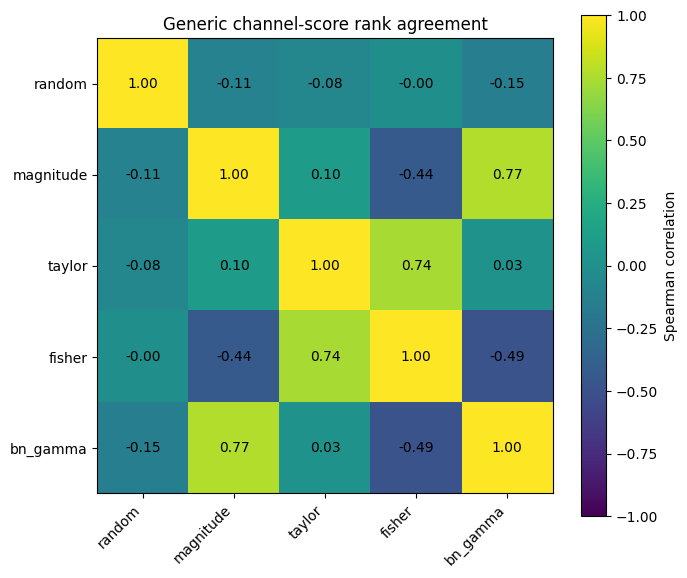

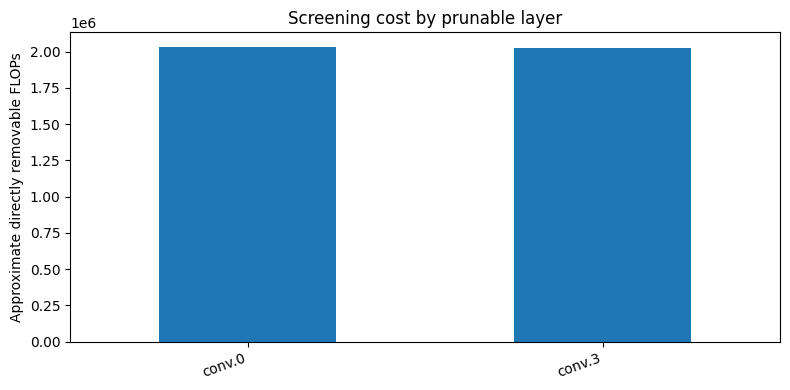

In [10]:
import matplotlib.pyplot as plt

corr = scores[score_columns].corr(method="spearman")
corr.to_csv(OUT / "baseline_score_spearman.csv")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Spearman correlation")
ax.set_title("Generic channel-score rank agreement")
fig.tight_layout()
fig.savefig(OUT / "baseline_score_rank_correlation.png", dpi=250)
plt.show()

layer_cost = (
    scores.groupby("module_path", as_index=False)
    .agg(channels=("group_id", "count"), flops=("flops_cost", "sum"))
)
ax = layer_cost.plot(x="module_path", y="flops", kind="bar", legend=False, figsize=(8, 4))
ax.set_ylabel("Approximate directly removable FLOPs")
ax.set_xlabel("")
ax.set_title("Screening cost by prunable layer")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUT / "removable_cost_by_layer.png", dpi=250, bbox_inches="tight")
plt.show()

## 6. Optional physical-surgery smoke test

A single non-critical channel from each layer is removed. This is not a result;
it checks that dimensional dependencies and forward execution remain correct.

In [11]:
from copy import deepcopy
from src.saber.surgery import prune_cnn1d_channels, count_parameters

smoke_map = {}
for layer, frame in groups.groupby("module_path"):
    # Remove the lowest-magnitude channel only.
    chosen = (
        scores[scores["module_path"] == layer]
        .nsmallest(1, "magnitude")["channel_index"]
        .astype(int)
        .tolist()
    )
    smoke_map[layer] = chosen

smoke_model, smoke_audit = prune_cnn1d_channels(
    MODEL,
    smoke_map,
    EXAMPLE_INPUT.to(DEVICE),
    minimum_remaining_per_layer=int(
        SABER_CFG["groups"]["minimum_remaining_per_layer"]
    ),
)
print("Parameters:", count_parameters(MODEL), "->", count_parameters(smoke_model))
display(smoke_audit)
assert count_parameters(smoke_model) < count_parameters(MODEL)

Parameters: 29730 -> 29114


,module_path,old_in_channels,new_in_channels,old_out_channels,new_out_channels,removed,removed_indices,batchnorm_path,downstream_path,downstream_kind
0,conv.0,1,1,64,63,1,28,conv.2,conv.3,conv_in
1,conv.3,64,63,128,127,1,36,conv.5,head,linear_in


## 7. Freeze the screening baseline table

In [12]:
import subprocess
from src.saber.adapters import save_run_manifest

try:
    git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
except Exception:
    git_commit = None

artefacts = [
    OUT / "prunable_groups.csv",
    OUT / "group_baseline_scores.csv",
    OUT / "baseline_score_summary.csv",
    OUT / "baseline_score_spearman.csv",
    OUT / "baseline_score_rank_correlation.png",
    OUT / "removable_cost_by_layer.png",
]
save_run_manifest(
    OUT / "manifest.json",
    notebook="15_structured_pruning_baselines.ipynb",
    config=SABER_CFG,
    artifacts=artefacts,
    git_commit=git_commit,
)
print("Notebook 15 complete. Next: Notebook 16 causal score validation.")

Notebook 15 complete. Next: Notebook 16 causal score validation.
